#### Analyse exploratoire des données — Bank Marketing

**Auteur :** Josué  
**Objectif :** comprendre la structure, la qualité et les variables du jeu de données avant toute modélisation.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../../data/raw/bank-additional.csv")

##### Chargement des données

In [4]:
df = pd.read_csv(DATA_PATH, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [5]:
# Dimensions du jeu de données
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 4119
Nombre de colonnes : 21


#### Types des variables et valeurs non nulles

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [22]:
# Tableau des valeurs manquantes par colonne
missing_summary = pd.DataFrame(
    {
        "nombre_valeurs_manquantes": df.isna().sum(),
        "pourcentage_valeurs_manquantes": (
            df.isna().mean() * 100
        ).round(2),
    }
)

# Afficher uniquement les colonnes qui ont au moins une valeur manquante
missing_summary[missing_summary["nombre_valeurs_manquantes"] > 0]

missing_summary

,nombre_valeurs_manquantes,pourcentage_valeurs_manquantes
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
month,0,0.0
day_of_week,0,0.0


In [7]:
# Statistiques descriptives des variables numériques et catégorielles
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
target_distribution = (
    df["y"]
    .value_counts()
    .rename_axis("souscription")
    .reset_index(name="effectif")
)

target_distribution["pourcentage"] = (
    target_distribution["effectif"] / len(df) * 100
).round(2)

target_distribution

,souscription,effectif,pourcentage
0,no,3668,89.05
1,yes,451,10.95


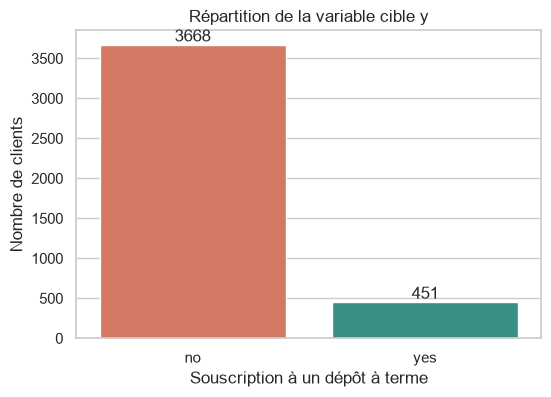

In [16]:
# Graphique de répartition de la cible
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="y",
    hue="y",
    palette={"no": "#E76F51", "yes": "#2A9D8F"},
    legend=False,
)

plt.title("Répartition de la variable cible y")
plt.xlabel("Souscription à un dépôt à terme")
plt.ylabel("Nombre de clients")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [12]:
categorical_columns = (
    df.select_dtypes(include=["object", "string"])
    .columns
    .drop("y")
)

unknown_summary = pd.DataFrame(
    {
        "nombre_unknown": [
            (df[column] == "unknown").sum()
            for column in categorical_columns
        ],
        "pourcentage_unknown": [
            round((df[column] == "unknown").mean() * 100, 2)
            for column in categorical_columns
        ],
    },
    index=categorical_columns,
).sort_values("nombre_unknown", ascending=False)

unknown_summary

,nombre_unknown,pourcentage_unknown
default,803,19.50
education,167,4.05
housing,105,2.55
loan,105,2.55
job,39,0.95
marital,11,0.27
contact,0,0.00
month,0,0.00
day_of_week,0,0.00
poutcome,0,0.00


In [11]:
pdays_999_percentage = (df["pdays"] == 999).mean() * 100

print(
    f"Part des clients avec pdays = 999 : "
    f"{pdays_999_percentage:.2f} %"
)

Part des clients avec pdays = 999 : 96.12 %


#### Premières observations

- Le jeu de données contient 4 119 observations et 20 variables explicatives.
- La cible `y` est déséquilibrée : les non-souscripteurs sont largement majoritaires.
- Aucune valeur manquante technique n’est présente, mais certaines variables qualitatives contiennent la modalité `unknown`.
- La valeur `999` de `pdays` représente un client qui n’a pas été contacté lors d’une campagne précédente.
- La variable `duration` sera exclue du modèle final, car elle n’est connue qu’après l’appel téléphonique.

#### Modalités `unknown`

Aucune valeur manquante technique n’est présente. Cependant, plusieurs variables catégorielles comportent une modalité `unknown`.

La variable `default` est particulièrement concernée, avec 19,50 % de modalités `unknown`. Cette modalité sera conservée dans le modèle baseline afin de ne pas perdre une information potentiellement utile.

Les modalités `unknown` de `housing`, `loan`, `job` et `marital` sont moins fréquentes. Leur regroupement éventuel sera étudié ultérieurement comme une expérience de prétraitement.

#### Variable `pdays`

La valeur `999` apparaît dans 96,12 % des observations. Elle ne correspond pas à une durée réelle : elle indique qu’aucun contact n’a eu lieu lors d’une campagne précédente.

Cette variable nécessite donc un traitement spécifique avant la modélisation. Une variable binaire indiquant l’existence d’un contact antérieur sera créée dans le pipeline de prétraitement.

In [13]:
target_distribution = (
    df["y"]
    .value_counts()
    .rename_axis("souscription")
    .reset_index(name="effectif")
)

target_distribution["pourcentage"] = (
    target_distribution["effectif"] / len(df) * 100
).round(2)

target_distribution

,souscription,effectif,pourcentage
0,no,3668,89.05
1,yes,451,10.95


#### Déséquilibre de la variable cible

La classe `no` est largement majoritaire, tandis que les clients ayant souscrit (`yes`) représentent une minorité de l’échantillon.

Ce déséquilibre implique que l’accuracy seule ne sera pas suffisante pour évaluer les modèles. Les métriques retenues seront notamment :

- ROC-AUC ;
- F1-score ;
- recall / sensibilité de la classe `yes` ;
- precision ;
- matrice de confusion.

### Analyse univariée des variables numériques

Cette section décrit la distribution des principales variables numériques avant toute transformation.

In [17]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

numeric_summary = (
    df[numeric_columns]
    .describe()
    .T
    .round(2)
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,4119.0,40.11,10.31,18.00,32.00,38.00,47.00,88.00
duration,4119.0,256.79,254.70,0.00,103.00,181.00,317.00,3643.00
campaign,4119.0,2.54,2.57,1.00,1.00,2.00,3.00,35.00
pdays,4119.0,960.42,191.92,0.00,999.00,999.00,999.00,999.00
previous,4119.0,0.19,0.54,0.00,0.00,0.00,0.00,6.00
emp.var.rate,4119.0,0.08,1.56,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,4119.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,4119.0,-40.50,4.59,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,4119.0,3.62,1.73,0.64,1.33,4.86,4.96,5.04
nr.employed,4119.0,5166.48,73.67,4963.60,5099.10,5191.00,5228.10,5228.10


#### Observations sur les variables numériques

- L’âge médian est de 38 ans, avec 50 % des clients compris entre 32 et 47 ans.
- La variable `campaign` est asymétrique : la majorité des clients sont contactés une à trois fois, mais certains le sont jusqu’à 35 fois.
- La variable `previous` est très concentrée sur 0 : la plupart des clients n’ont pas eu de contact antérieur.
- La variable `pdays` ne peut pas être interprétée directement, car 96,12 % de ses valeurs sont égales à 999.
- Les variables macroéconomiques devront être étudiées pour détecter d’éventuelles corrélations fortes.
- Médiane duration pour y = no  : 165 secondes
Médiane duration pour y = yes : 458 secondes

La durée moyenne est aussi beaucoup plus élevée chez les souscripteurs : environ 561 secondes contre 219 secondes. Cela confirme la fuite d’information : cette variable serait très performante, mais non disponible avant l’appel.


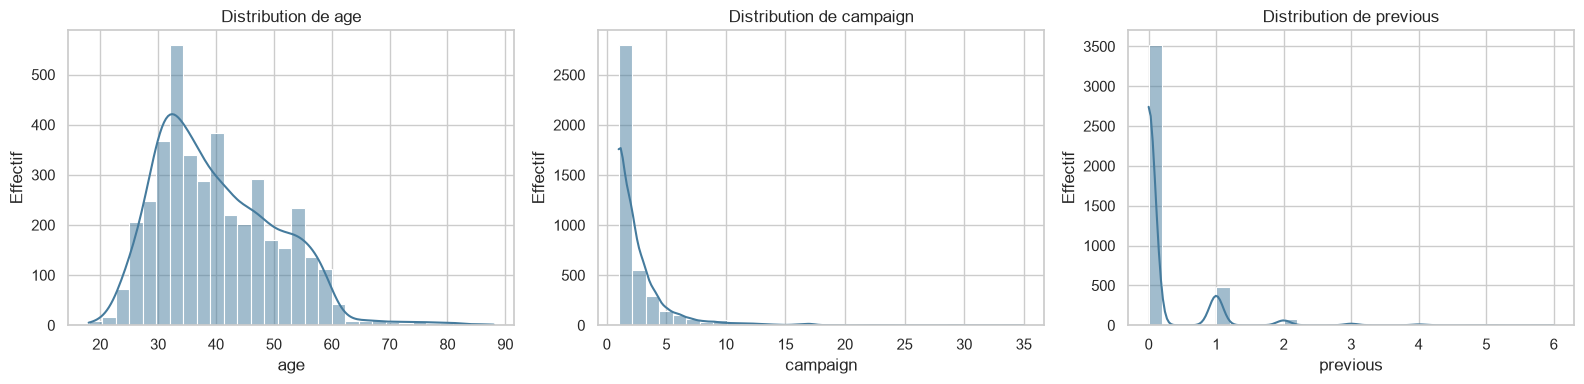

In [18]:
selected_numeric_columns = ["age", "campaign", "previous"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 4),
)

for ax, column in zip(axes, selected_numeric_columns):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        ax=ax,
        color="#457B9D",
    )
    ax.set_title(f"Distribution de {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Effectif")

plt.tight_layout()
plt.show()

In [19]:
duration_by_target = (
    df.groupby("y")["duration"]
    .describe()
    .round(2)
)

duration_by_target

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,3668.0,219.41,198.26,0.0,96.0,165.0,274.0,3253.0
yes,451.0,560.79,411.54,63.0,255.5,458.0,761.0,3643.0


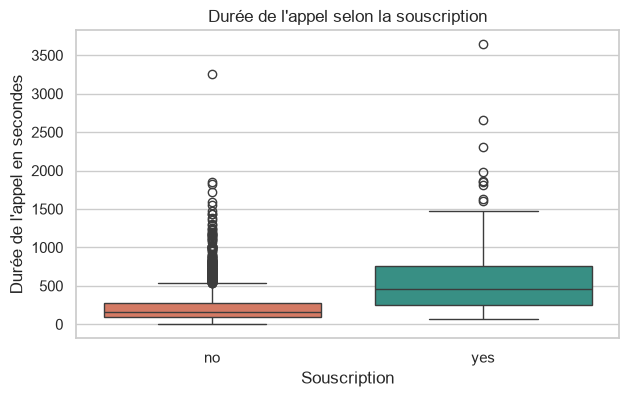

In [20]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="y",
    y="duration",
    hue="y",
    palette={"no": "#E76F51", "yes": "#2A9D8F"},
    legend=False,
)

plt.title("Durée de l'appel selon la souscription")
plt.xlabel("Souscription")
plt.ylabel("Durée de l'appel en secondes")
plt.show()

### Analyse univariée des variables catégorielles

Cette section présente la distribution des principales variables catégorielles du jeu de données.

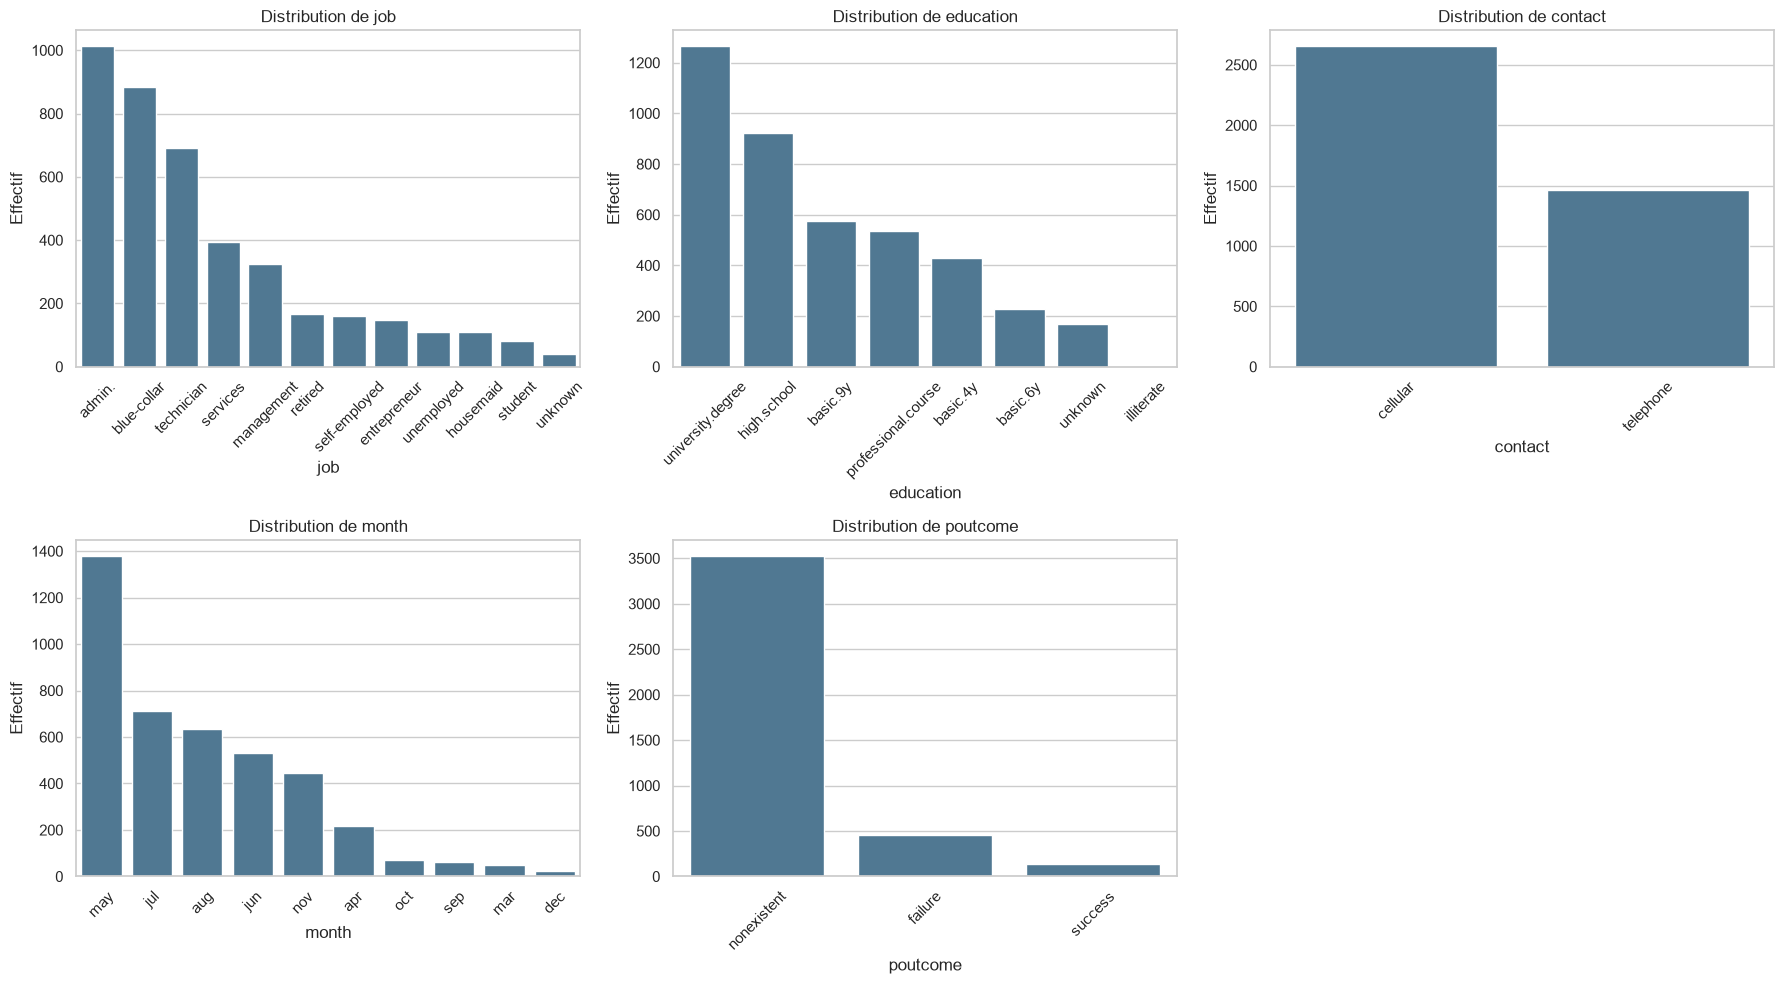

In [24]:
categorical_to_plot = ["job", "education", "contact", "month", "poutcome"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10),
)

for ax, column in zip(axes.flat, categorical_to_plot):
    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index,
        color="#457B9D",
        ax=ax,
    )
    ax.set_title(f"Distribution de {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Effectif")
    ax.tick_params(axis="x", rotation=45)

# Masquer la dernière case vide de la grille
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
job_subscription_rate = (
    df.groupby("job")["y"]
    .apply(lambda values: (values == "yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
    .rename("taux_souscription_pct")
    .reset_index()
)

job_subscription_rate

,job,taux_souscription_pct
0,student,23.17
1,retired,22.89
2,unemployed,17.12
3,admin.,13.14
4,technician,11.58
5,unknown,10.26
6,housemaid,10.00
7,management,9.26
8,services,8.91
9,self-employed,8.18


#### Souscription selon la profession

Le taux de souscription varie selon la profession. Les catégories `student` et `retired` présentent les taux les plus élevés, tandis que `entrepreneur` et `blue-collar` présentent les taux les plus faibles.

Ces résultats doivent être interprétés avec prudence, car certaines professions comportent peu d’observations.

In [26]:
def subscription_summary(data, column):
    """Calcule les effectifs et taux de souscription par modalité."""

    summary = (
        data.assign(subscribed=data["y"].eq("yes"))
        .groupby(column)
        .agg(
            effectif=("y", "size"),
            nombre_souscriptions=("subscribed", "sum"),
            taux_souscription_pct=("subscribed", "mean"),
        )
        .reset_index()
    )

    summary["taux_souscription_pct"] = (
        summary["taux_souscription_pct"] * 100
    ).round(2)

    return summary.sort_values(
        "taux_souscription_pct",
        ascending=False,
    )

In [27]:
for column in ["poutcome", "contact", "month"]:
    print(f"\n--- {column} ---")
    display(subscription_summary(df, column))


--- poutcome ---


,poutcome,effectif,nombre_souscriptions,taux_souscription_pct
2,success,142,92,64.79
0,failure,454,67,14.76
1,nonexistent,3523,292,8.29



--- contact ---


,contact,effectif,nombre_souscriptions,taux_souscription_pct
0,cellular,2652,375,14.14
1,telephone,1467,76,5.18



--- month ---


,month,effectif,nombre_souscriptions,taux_souscription_pct
5,mar,48,28,58.33
2,dec,22,12,54.55
9,sep,64,26,40.62
8,oct,69,25,36.23
0,apr,215,36,16.74
4,jun,530,68,12.83
1,aug,636,64,10.06
7,nov,446,43,9.64
3,jul,711,59,8.30
6,may,1378,90,6.53


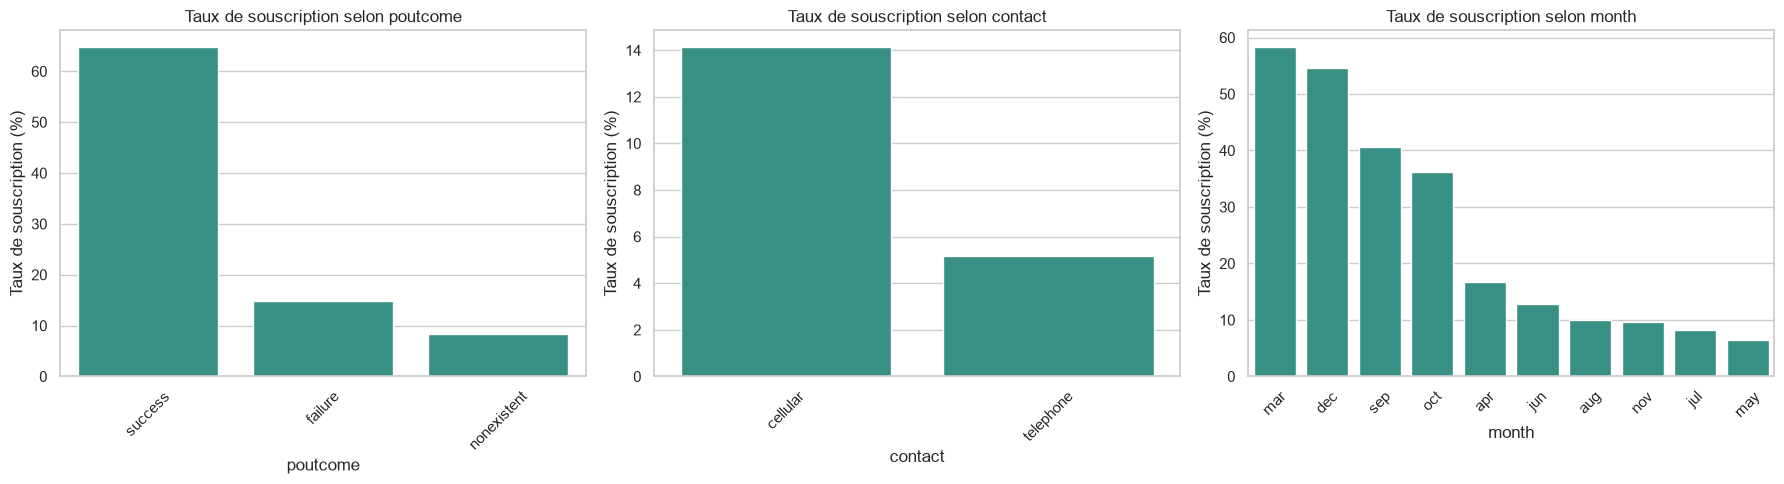

In [28]:
variables_to_compare = ["poutcome", "contact", "month"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
)

for ax, column in zip(axes, variables_to_compare):
    summary = subscription_summary(df, column)

    sns.barplot(
        data=summary,
        x=column,
        y="taux_souscription_pct",
        color="#2A9D8F",
        ax=ax,
    )

    ax.set_title(f"Taux de souscription selon {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Taux de souscription (%)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Souscription selon l’historique, le canal et le mois

- `poutcome` est une variable très informative : 64,79 % des clients ayant déjà connu un succès lors d’une campagne précédente souscrivent à nouveau, contre 8,29 % lorsque le client n’a pas été contacté auparavant.
- Les clients contactés par téléphone mobile (`cellular`) souscrivent davantage que ceux contactés par téléphone fixe (`telephone`) : 14,14 % contre 5,18 %.
- Le taux de souscription varie fortement selon le mois. Toutefois, les mois de décembre, mars, septembre et octobre ont des effectifs faibles : leurs taux élevés doivent être interprétés avec prudence.
- Le mois de mai représente le plus grand effectif, mais présente un taux de souscription relativement faible : 6,53 %.

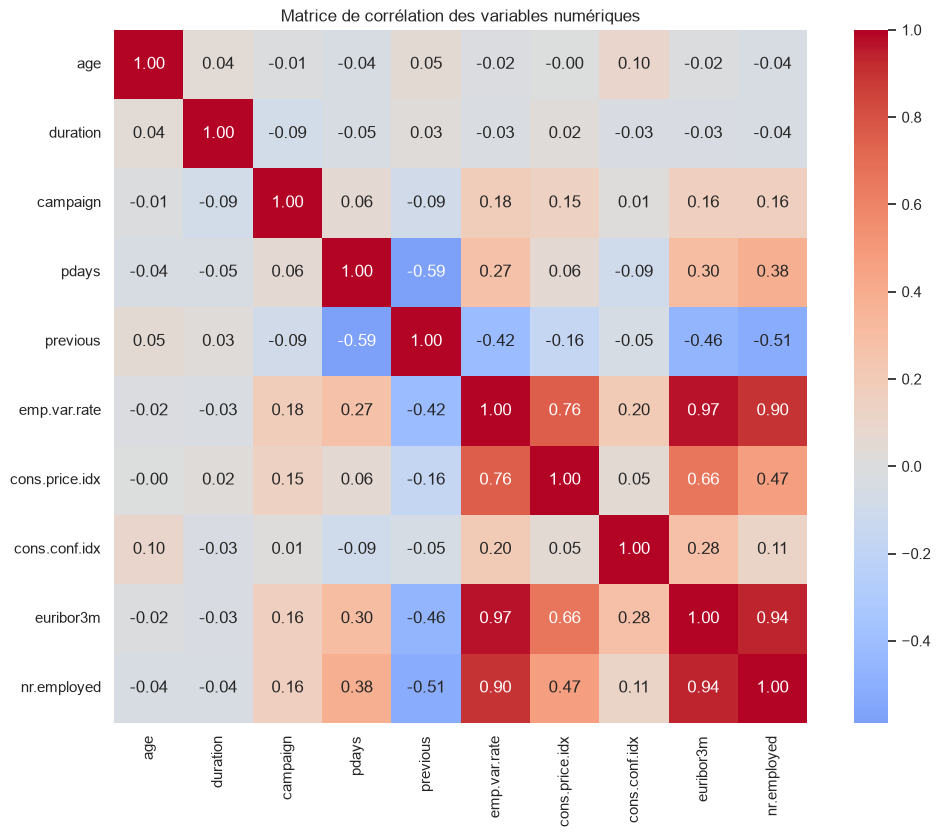

In [30]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

#### Corrélations entre variables numériques

Les variables macroéconomiques `emp.var.rate`, `euribor3m` et `nr.employed` présentent de très fortes corrélations. Elles portent donc une information largement redondante.

Pour le modèle baseline de régression logistique, seule la variable `euribor3m` sera retenue parmi ces variables fortement corrélées. Les autres variables pourront être comparées dans des expériences ultérieures.

La variable `pdays` est négativement corrélée à `previous`. Cette relation est cohérente avec la valeur sentinelle `999` utilisée pour signaler l’absence de contact précédent.

In [32]:
numeric_features_for_target = [
    "age",
    "campaign",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
]

numeric_target_summary = (
    df.groupby("y")[numeric_features_for_target]
    .agg(["mean", "median"])
    .T
    .round(2)
)

numeric_target_summary

y                           no      yes
age            mean      39.90    41.89
               median    38.00    39.00
campaign       mean       2.61     1.98
               median     2.00     2.00
previous       mean       0.14     0.59
               median     0.00     0.00
emp.var.rate   mean       0.24    -1.18
               median     1.10    -1.80
cons.price.idx mean      93.60    93.42
               median    93.92    93.37
cons.conf.idx  mean     -40.59   -39.79
               median   -41.80   -40.30
euribor3m      mean       3.80     2.15
               median     4.86     1.26
nr.employed    mean    5175.50  5093.12
               median  5195.80  5076.20

#### Variables numériques selon la souscription

Les clients ayant souscrit sont légèrement plus âgés que les non-souscripteurs.

Le nombre moyen de contacts dans la campagne courante (`campaign`) est plus faible chez les souscripteurs. Cela peut indiquer qu’une sollicitation trop répétée est associée à une probabilité de souscription plus faible.

La variable `previous` est plus élevée chez les souscripteurs, ce qui suggère qu’un historique de contact est informatif.

Les variables macroéconomiques présentent des différences importantes selon la cible. Cependant, plusieurs d’entre elles sont fortement corrélées. La variable `euribor3m` sera privilégiée dans le modèle baseline.

In [33]:
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    """Calcule le V de Cramer et la p-value du test du chi-deux."""

    contingency_table = pd.crosstab(x, y)

    chi2, p_value, _, _ = chi2_contingency(contingency_table)

    n_observations = contingency_table.to_numpy().sum()
    min_dimension = min(contingency_table.shape) - 1

    v_cramer = np.sqrt(chi2 / (n_observations * min_dimension))

    return v_cramer, p_value

In [34]:
categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
]

association_results = []

for column in categorical_features:
    v_cramer, p_value = cramers_v(df[column], df["y"])

    association_results.append(
        {
            "variable": column,
            "v_cramer": round(v_cramer, 3),
            "p_value": p_value,
        }
    )

categorical_associations = (
    pd.DataFrame(association_results)
    .sort_values("v_cramer", ascending=False)
    .reset_index(drop=True)
)

categorical_associations

,variable,v_cramer,p_value
0,poutcome,0.332,2.039413e-99
1,month,0.270,2.894875e-59
2,contact,0.137,1.848000e-18
3,job,0.130,1.233132e-10
4,default,0.077,5.599508e-06
5,education,0.074,2.262143e-03
6,marital,0.050,1.628573e-02
7,loan,0.017,5.684489e-01
8,housing,0.012,7.307440e-01
9,day_of_week,0.011,9.723049e-01


Le tableau ci-dessus montre l’association de chaque variable catégorielle avec la cible y :
- poutcome est la plus informative (V = 0.332) ;
- month est aussi assez liée à la souscription (V = 0.270) ;
- contact et job ont une association faible à modérée ;
- housing, loan et day_of_week n’apportent presque rien ici.
Les p_value confirment que les associations fortes ne sont pas dues au hasard. Mais pour choisir les variables, on regarde surtout V de Cramer, pas uniquement la p-value.

In [35]:
# Mesurer l'association entre chaque paire de variables catégorielles
categorical_predictors = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
]

cramers_matrix = pd.DataFrame(
    np.eye(len(categorical_predictors)),
    index=categorical_predictors,
    columns=categorical_predictors,
)

for row_variable in categorical_predictors:
    for column_variable in categorical_predictors:
        if row_variable != column_variable:
            v_cramer, _ = cramers_v(df[row_variable], df[column_variable])
            cramers_matrix.loc[row_variable, column_variable] = round(v_cramer, 3)

cramers_matrix

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
job,1.000,0.184,0.355,0.165,0.072,0.062,0.131,0.118,0.056,0.104
marital,0.184,1.000,0.107,0.095,0.016,0.015,0.087,0.062,0.033,0.036
education,0.355,0.107,1.000,0.173,0.060,0.051,0.149,0.098,0.053,0.053
default,0.165,0.095,0.173,1.000,0.017,0.012,0.151,0.118,0.035,0.080
housing,0.072,0.016,0.060,0.017,1.000,0.709,0.075,0.068,0.022,0.024
loan,0.062,0.015,0.051,0.012,0.709,1.000,0.018,0.034,0.028,0.019
contact,0.131,0.087,0.149,0.151,0.075,0.018,1.000,0.603,0.068,0.251
month,0.118,0.062,0.098,0.118,0.068,0.034,0.603,1.000,0.087,0.250
day_of_week,0.056,0.033,0.053,0.035,0.022,0.028,0.068,0.087,1.000,0.027
poutcome,0.104,0.036,0.053,0.080,0.024,0.019,0.251,0.250,0.027,1.000


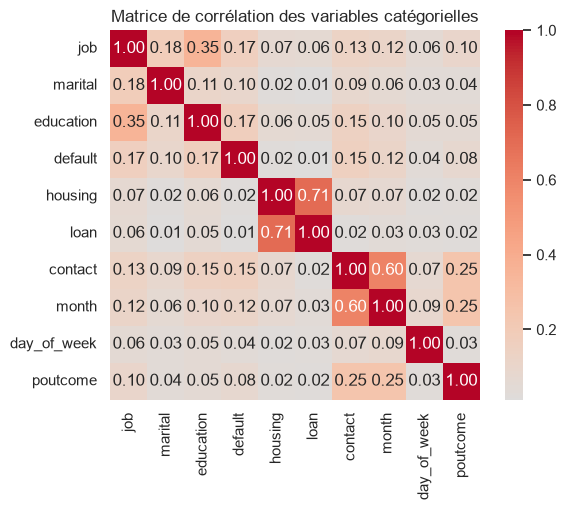

In [36]:
sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Matrice de corrélation des variables catégorielles")
plt.show()

In [38]:
from scipy.stats import ttest_ind

# Variables numériques à comparer entre les clients ayant souscrit ou non
numeric_features = [
    "age",
       "campaign",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed","duration"
]

student_results = []

for column in numeric_features:
    group_no = df.loc[df["y"] == "no", column]
    group_yes = df.loc[df["y"] == "yes", column]

    # equal_var=False : version de Welch, plus robuste si les variances diffèrent
    statistic, p_value = ttest_ind(
        group_no,
        group_yes,
        equal_var=False,
    )

    student_results.append(
        {
            "variable": column,
            "moyenne_no": round(group_no.mean(), 2),
            "moyenne_yes": round(group_yes.mean(), 2),
            "statistique_t": round(statistic, 3),
            "p_value": p_value,
        }
    )

student_table = (
    pd.DataFrame(student_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

student_table

,variable,moyenne_no,moyenne_yes,statistique_t,p_value
0,euribor3m,3.80,2.15,18.915,8.018937e-62
1,nr.employed,5175.50,5093.12,18.710,7.273103e-60
2,emp.var.rate,0.24,-1.18,17.513,8.518090e-55
3,duration,219.41,560.79,-17.370,1.050221e-52
4,previous,0.14,0.59,-9.281,6.175277e-19
5,campaign,2.61,1.98,8.007,3.447996e-15
6,cons.price.idx,93.60,93.42,5.405,9.868732e-08
7,age,39.90,41.89,-3.083,2.162114e-03
8,cons.conf.idx,-40.59,-39.79,-2.772,5.767023e-03


In [39]:
from scipy.stats import f_oneway

# Variables catégorielles à plusieurs modalités
categorical_features_anova = [
    "job",
    "marital",
    "education",
    "contact",
    "month",
    "poutcome",
]

# Variables quantitatives dont on veut comparer les moyennes
numeric_features_anova = [
    "age",
    "campaign",
    "previous",
    "euribor3m",
]

anova_results = []

for categorical_column in categorical_features_anova:
    for numeric_column in numeric_features_anova:
        # Créer un groupe de valeurs numériques pour chaque modalité
        groups = [
            group[numeric_column].dropna()
            for _, group in df.groupby(categorical_column)
        ]

        statistic_f, p_value = f_oneway(*groups)

        anova_results.append(
            {
                "variable_categorielle": categorical_column,
                "variable_numerique": numeric_column,
                "statistique_f": round(statistic_f, 3),
                "p_value": p_value,
            }
        )

anova_table = (
    pd.DataFrame(anova_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

anova_table

,variable_categorielle,variable_numerique,statistique_f,p_value
0,poutcome,previous,6092.578,0.000000e+00
1,month,euribor3m,215.012,0.000000e+00
2,poutcome,euribor3m,707.038,1.121618e-264
3,job,age,111.426,2.566734e-223
4,marital,age,302.469,1.895014e-177
5,contact,euribor3m,739.925,5.526406e-150
6,month,previous,48.377,1.283284e-83
7,education,age,45.288,3.900723e-62
8,contact,previous,200.435,1.826014e-44
9,month,campaign,13.424,1.971121e-21


## Synthèse des relations entre variables

### Variables numériques entre elles

Les variables macroéconomiques présentent de fortes corrélations :

- `emp.var.rate` et `euribor3m` : corrélation très forte ;
- `euribor3m` et `nr.employed` : corrélation très forte ;
- `emp.var.rate` et `nr.employed` : corrélation forte ;
- `pdays` et `previous` : corrélation négative importante.

Afin de limiter la redondance dans le modèle de référence, une seule variable
macroéconomique, probablement `euribor3m`, sera retenue dans un premier temps.
La variable `pdays` devra être transformée car 96,12 % de ses valeurs sont égales
à `999`, ce qui signifie qu'aucun contact précédent n'a eu lieu.

### Variables catégorielles entre elles

Les associations les plus importantes, mesurées avec le V de Cramer, sont :

- `housing` et `loan` (`V = 0.709`) ;
- `contact` et `month` (`V = 0.603`) ;
- `job` et `education` (`V = 0.355`) ;
- `contact` et `poutcome` (`V = 0.251`) ;
- `month` et `poutcome` (`V = 0.250`).

Ces associations indiquent une redondance partielle entre certaines variables.
Elles seront prises en compte lors de la sélection des variables et de
l'interprétation du modèle.

### Variables numériques et catégorielles

Le test de Student montre que les clients ayant souscrit présentent en moyenne :

- un `euribor3m`, un `nr.employed` et un `emp.var.rate` plus faibles ;
- moins de contacts durant la campagne (`campaign`) ;
- davantage de contacts antérieurs (`previous`) ;
- un âge légèrement plus élevé.

L'ANOVA met notamment en évidence des relations fortes entre :

- `poutcome` et `previous` ;
- `month`, `contact` et `euribor3m` ;
- `job`, `marital`, `education` et `age`.

### Décisions préliminaires pour la modélisation

- La cible `y` est déséquilibrée : environ 11 % de souscriptions.
- `duration` sera exclue du modèle prédictif, car elle n'est connue qu'après
  l'appel téléphonique.
- `pdays` sera transformée en indicateur de contact antérieur.
- `poutcome`, `month`, `contact`, `job`, `campaign`, `previous`, `age` et
  `euribor3m` sont des variables candidates pertinentes.
- La sélection finale sera réalisée uniquement sur les données d'entraînement,
  avec validation croisée.

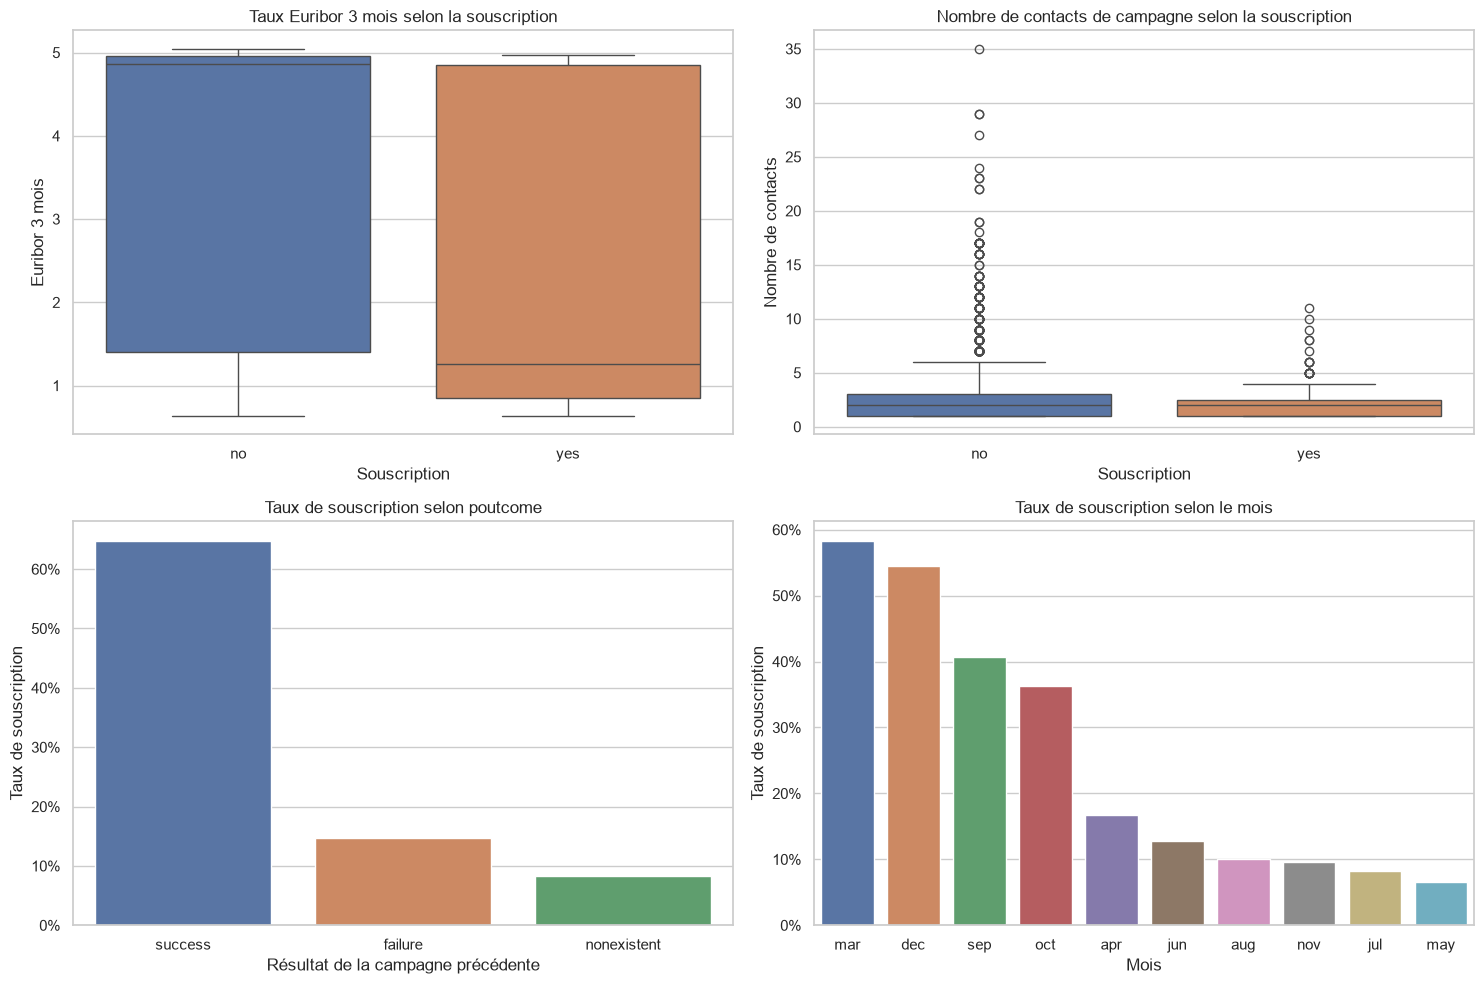

In [42]:
# Créer une variable booléenne pratique pour calculer les taux de souscription
eda_plot = df.assign(subscribed=df["y"].eq("yes"))

# Créer une grille de quatre graphiques exploratoires
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Comparer le taux d'intérêt euribor3m selon la souscription
sns.boxplot(
    data=eda_plot,
    x="y",
    y="euribor3m",
    hue="y",
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Taux Euribor 3 mois selon la souscription")
axes[0, 0].set_xlabel("Souscription")
axes[0, 0].set_ylabel("Euribor 3 mois")

# 2. Comparer le nombre de contacts de campagne selon la souscription
sns.boxplot(
    data=eda_plot,
    x="y",
    y="campaign",
    hue="y",
    legend=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Nombre de contacts de campagne selon la souscription")
axes[0, 1].set_xlabel("Souscription")
axes[0, 1].set_ylabel("Nombre de contacts")

# 3. Afficher le taux de souscription selon le résultat de campagne précédente
poutcome_rate = (
    eda_plot.groupby("poutcome", as_index=False)["subscribed"]
    .mean()
    .sort_values("subscribed", ascending=False)
)

sns.barplot(
    data=poutcome_rate,
    x="poutcome",
    y="subscribed",
    hue="poutcome",
    legend=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Taux de souscription selon poutcome")
axes[1, 0].set_xlabel("Résultat de la campagne précédente")
axes[1, 0].set_ylabel("Taux de souscription")
axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

# 4. Afficher le taux de souscription selon le mois de contact
month_rate = (
    eda_plot.groupby("month", as_index=False)["subscribed"]
    .mean()
    .sort_values("subscribed", ascending=False)
)

sns.barplot(
    data=month_rate,
    x="month",
    y="subscribed",
    hue="month",
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Taux de souscription selon le mois")
axes[1, 1].set_xlabel("Mois")
axes[1, 1].set_ylabel("Taux de souscription")
axes[1, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

# Ajuster automatiquement les espacements puis afficher les graphiques
plt.tight_layout()
plt.show()

### Visualisations bivariées

Les graphiques confirment les résultats des tests statistiques.

- Les clients ayant souscrit présentent généralement un taux `euribor3m` plus faible.
- Les souscriptions sont associées à un nombre de contacts de campagne plus faible.
  Les valeurs extrêmes de `campaign` sont principalement observées chez les clients
  qui n'ont pas souscrit.
- La variable `poutcome` est fortement discriminante : une campagne antérieure réussie
  est associée à un taux de souscription nettement plus élevé.
- Les taux de souscription diffèrent selon le mois de contact. Cette observation devra
  toutefois être interprétée avec prudence, car certains mois ont de faibles effectifs.

Ces graphiques confortent la sélection préliminaire de `euribor3m`, `campaign`,
`poutcome` et `month` comme variables candidates pour la modélisation.